### Графический пример

Загрузка библиотек

In [2]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

Построение графиков функций

In [3]:
# Some functions to plot our points and draw the models
def plot_points(features, labels, size_of_points=100):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = size_of_points,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = size_of_points,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    #pyplot.xlabel('GRE')
    #pyplot.ylabel('TOEFL')
    #pyplot.legend(['Admitted','Not admitted'])

In [4]:
def plot_model(X, y, model, size_of_points=100):
    X = np.array(X)
    y = np.array(y)
    plot_step = 0.2
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 1)
    plot_points(X, y, size_of_points)
    plt.show()

In [42]:
def display_tree(dt):

    from sklearn import tree
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 10))

    tree.plot_tree(
        dt,
        filled=True,
        rounded=True,
        fontsize=14
    )

    plt.show()

Исходный датасет

In [1]:
dataset = pd.DataFrame({
    'x_0':[7,3,2,1,2,4,1,8,6,7,8,9],
    'x_1':[1,2,3,5,6,7,9,10,5,8,4,6],
    'y': [0,0,0,0,0,0,1,1,1,1,1,1]})

dataset

NameError: name 'pd' is not defined

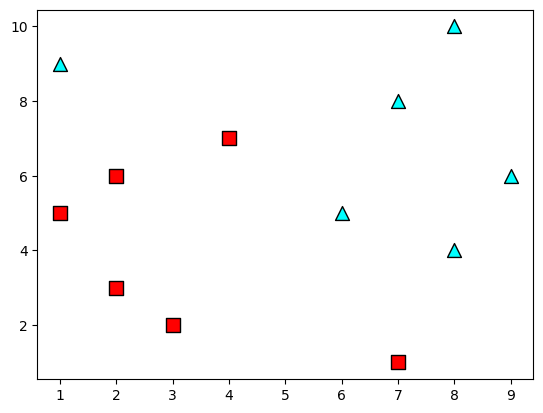

In [7]:
features = dataset[['x_0', 'x_1']]
labels = dataset['y']

plot_points(features, labels)

Построение дерева решений с использованием индекса Джини

In [29]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(features.values, labels.values)
decision_tree.score(features.values, labels.values)

1.0

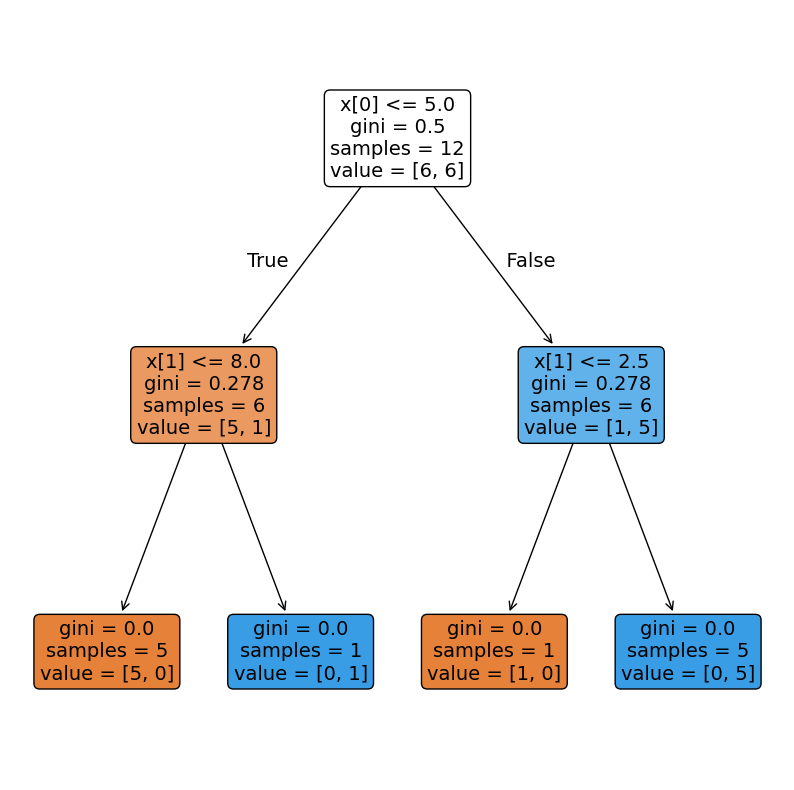

In [44]:
display_tree(decision_tree)

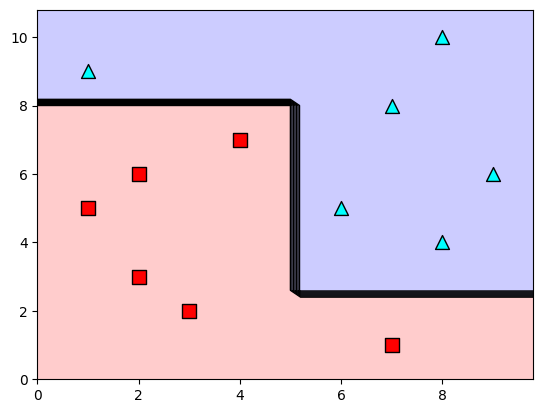

In [31]:
plot_model(features, labels, decision_tree)

Построение дерева решений с использованием энтропии

In [32]:
decision_tree_entropy = DecisionTreeClassifier(criterion='entropy')
decision_tree_entropy.fit(features.values, labels.values)
decision_tree_entropy.score(features.values, labels.values)

1.0

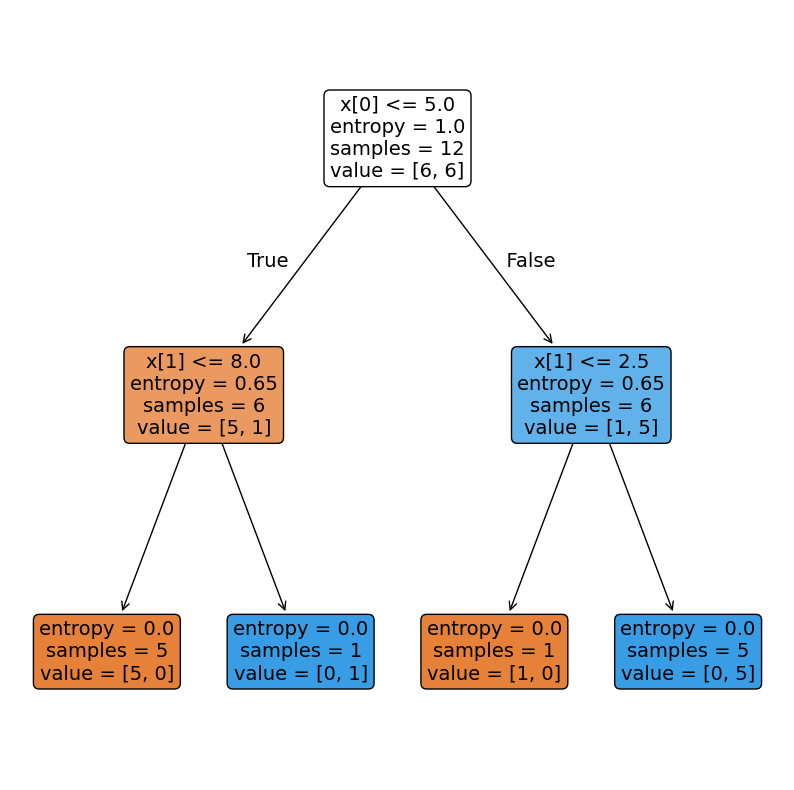

In [33]:
display_tree(decision_tree_entropy)

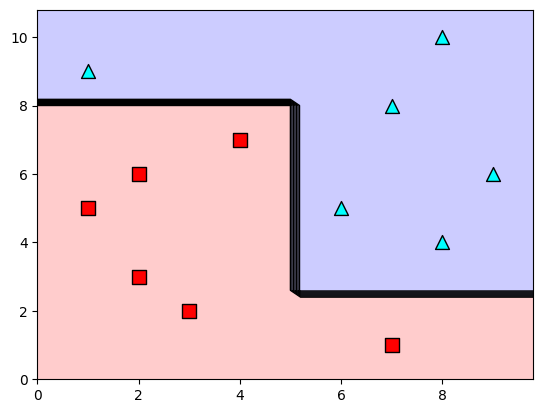

In [34]:
plot_model(features, labels, decision_tree_entropy)

Построение дерева решений глубиной один (вертикальная или горизонтальная линия)

In [35]:
decision_tree_depth_1 = DecisionTreeClassifier(max_depth=1)
decision_tree_depth_1.fit(features.values, labels.values)
decision_tree_depth_1.score(features.values, labels.values)

0.8333333333333334

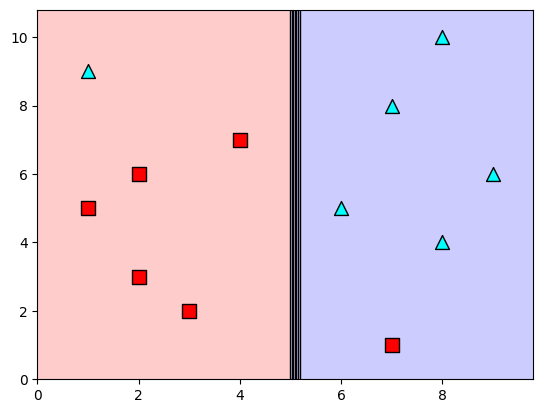

In [36]:
plot_model(features, labels, decision_tree_depth_1)

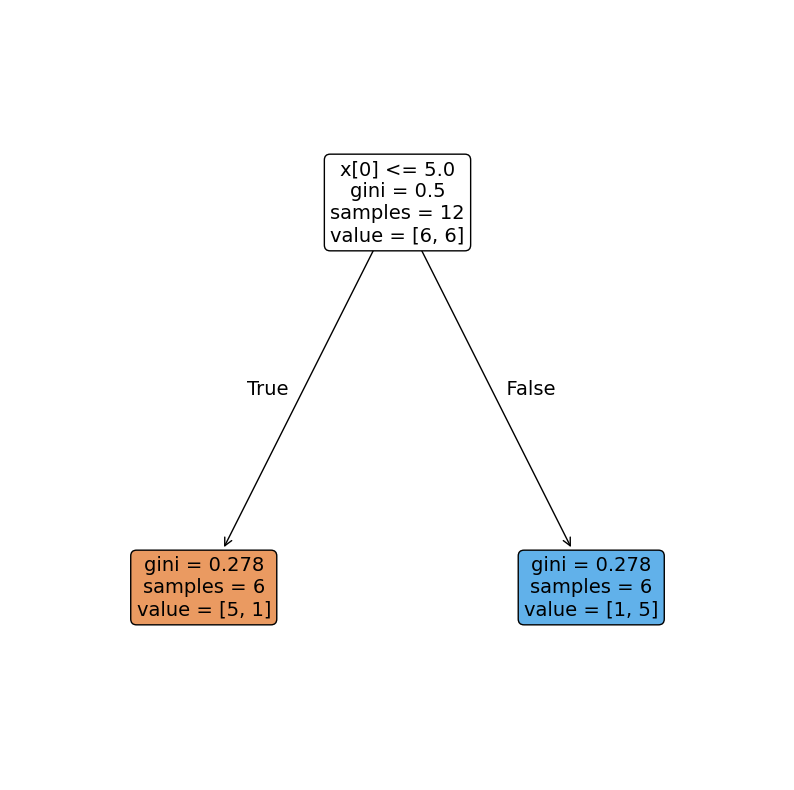

In [37]:
display_tree(decision_tree_depth_1)